In [34]:
import json
import matplotlib.pyplot as plt
from collections import Counter
import re

# Function to clean and fix JSON strings
def clean_json_string(json_str):
    # Remove any text before the first {
    json_str = re.sub(r'^.*?{', '{', json_str)
    # Replace 'NIL' with 'null' and 'FALSE'/'TRUE' with 'false'/'true'
    json_str = re.sub(r'(\s*NIL\s*)', 'null', json_str)
    json_str = re.sub(r'(\s*FALSE\s*)', 'false', json_str)
    json_str = re.sub(r'(\s*TRUE\s*)', 'true', json_str)
    json_str = re.sub(r'(\s*False\s*)', 'false', json_str)
    json_str = re.sub(r'(\s*True\s*)', 'true', json_str)
    # Fix common JSON errors
    json_str = re.sub(r',\s*}', '}', json_str)  # Remove trailing commas before }
    json_str = re.sub(r',\s*\]', ']', json_str)  # Remove trailing commas before ]
    json_str = re.sub(r'(\n)', '', json_str)     # Remove newlines
    json_str = re.sub(r'\s+', ' ', json_str)     # Remove extra spaces

    if json_str.count('{') > json_str.count('}'):
        json_str += '}'
    if json_str.count('[') > json_str.count(']'):
        json_str += ']'

    json_str = json_str.strip()
    return json_str

# Load JSON data from a file
with open('data.json', 'r') as file:
    data = json.load(file)

# Initialize a counter for modalities
modality_counter = Counter()

# Process each entry in the data
for key, value in data.items():
    # if key != '33118957':
    #     continue
    # Clean the nested JSON string
    clean_value = clean_json_string(value)
    clean_value = re.sub(r'^.*?{', '{', clean_value)
    # print('------>>', clean_value)
    # Load the cleaned JSON string
    try:
        record = json.loads(clean_value)
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON for key {key}: {e}, {clean_value}")
        
    # Extract the modalities
    modalities = record.get("Modalities", [])
    # If modalities is null or empty, skip
    if modalities is None or not modalities:
        continue
    # Update the counter with the modalities
    for modality in modalities:
        if isinstance(modality, dict):
            modality_counter.update(modality.keys())
        else:
            modality_counter.update([modality])

# # Prepare data for plotting
# if modality_counter:
#     labels, counts = zip(*modality_counter.items())

#     # Plotting the data
#     plt.figure(figsize=(10, 6))
#     plt.bar(labels, counts, color='skyblue')
#     plt.xlabel('Modalities')
#     plt.ylabel('Count')
#     plt.title('Distribution of Modalities')
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()
# else:
#     print("No modalities found to plot.")


Error decoding JSON for key 29620521: Expecting ':' delimiter: line 1 column 289 (char 288), {"Affiliation_countries_tags": ["Canada"],"Centralized_or_Decentralized": "Decentralized","Is_Real_World_Data_Set": false,"Size_of_Data_Set": { "images": 400000, "experiments": 24},"AI_or_ML_Tools_In_The_Paper": [ {"Department of Computer Science, University of Toronto, Toronto, Canada."}, {"Terrence Donnelly Centre for Cellular and Biomolecular Research, University of Toronto, Toronto, Canada."}, {"Department of Cell and Systems Biology, University of Toronto, Toronto, Canada."}, {"Department of Electrical and Computer Engineering, University of Toronto, Toronto, Canada."}],"Governance_Mode":null,"Patient_Level_Data": false,"Type_of_Patient_Level_Data":null,"Clinical_Data_Type":null,"Is_Using_Survey_Data": false,"Is_Using_Questionnaire": false,"Federated_Learning_Techniques":null,"Privacy_Preserving_Techniques":null,"Data_Collection_Method": [ "microscopy screens"],"Is_Using_Large_Language_Mod

In [9]:
record

{'Affiliation_countries_tags': ['Canada', 'TX', 'UK', 'NC', 'MA', 'MO'],
 'Countries': ['Canada',
  'United Kingdom',
  'Massachusetts',
  'Texas',
  'North Carolina',
  'Missouri'],
 'Centralized_or_Decentralized': 'null',
 'Is_Real_World_Data_Set': True,
 'Size_of_Data_Set': 290,
 'Ai_or_Ml_Tools_In_The_Paper': ['Deep learning'],
 'Governance_Mode': 'null',
 'Patient_Level_Data': False,
 'Type_of_Patient_Level_Data': 'null',
 'Clinical_Data_Type': 'null',
 'Is_Using_Survey_Data': False,
 'Is_Using_Questionnaire': False,
 'Federated_Learning_Techniques': 'null',
 'Privacy_Preserving_Techniques': 'null',
 'Data_Collection_Method': 'Annotations were performed by 4 high-volume surgeons.',
 'Is_Using_Large_Language_Model': False,
 'Is_Using_Multimodal_Model': True,
 'Is_Using_Shared_Dataset': True,
 'Modalities': ['Video']}

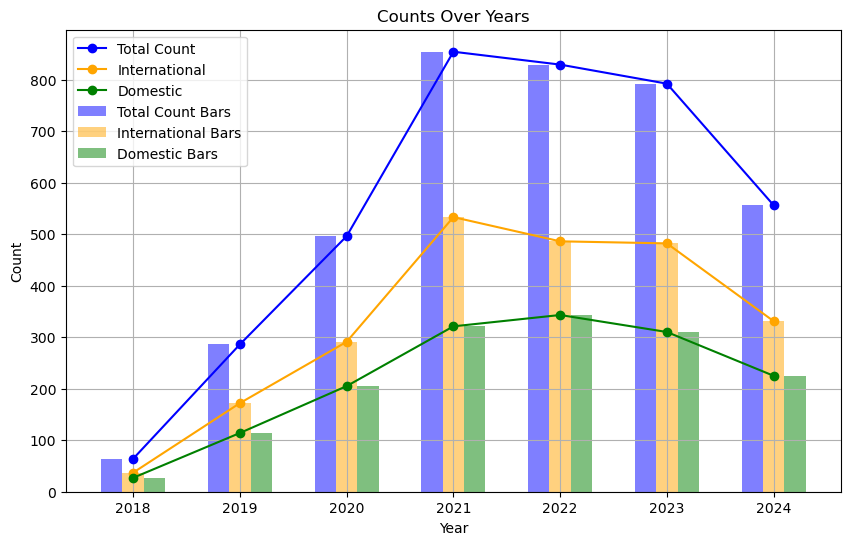

In [3]:
import matplotlib.pyplot as plt

# Data for the years and counts
years = [2018, 2019, 2020, 2021, 2022, 2023, 2024]
total_count = [64, 286, 496, 854, 829, 792, 556]
international_count = [37, 172, 291, 533, 486, 482, 331]
domestic_count = [27, 114, 205, 321, 343, 310, 225]

# Plotting the data with both line and bar charts
plt.figure(figsize=(10, 6))

# Line plots
plt.plot(years, total_count, marker='o', label='Total Count', color='blue')
plt.plot(years, international_count, marker='o', label='International', color='orange')
plt.plot(years, domestic_count, marker='o', label='Domestic', color='green')

# Bar charts
plt.bar([x - 0.2 for x in years], total_count, width=0.2, color='blue', alpha=0.5, label='Total Count Bars')
plt.bar([x for x in years], international_count, width=0.2, color='orange', alpha=0.5, label='International Bars')
plt.bar([x + 0.2 for x in years], domestic_count, width=0.2, color='green', alpha=0.5, label='Domestic Bars')

# Adding title and labels
plt.title('Counts Over Years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(years)
plt.grid(True)
plt.legend()

# Show plot
plt.show()



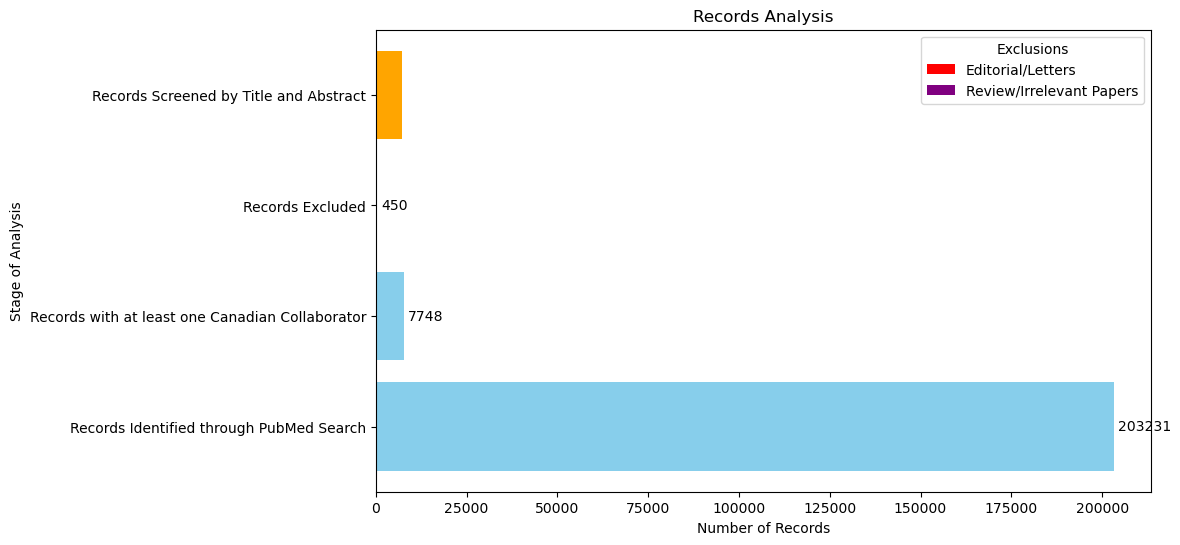

In [4]:
import matplotlib.pyplot as plt

# Data for the chart
labels = [
    'Records Identified through PubMed Search',
    'Records with at least one Canadian Collaborator',
    'Records Excluded',
    'Records Screened by Title and Abstract'
]

values = [203231, 7748, 450, 7298]

# Subdivision of excluded records
excluded_labels = ['Editorial/Letters', 'Review/Irrelevant Papers']
excluded_values = [260, 190]

# Create a figure and axis for the main data
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the main data
ax.barh(labels[:-1], values[:-1], color='skyblue')
ax.barh(labels[-1], values[-1], color='orange')

# Plot the excluded records as a stacked bar
ax.barh(labels[2], excluded_values[0], color='red', label=excluded_labels[0])
ax.barh(labels[2], excluded_values[1], left=excluded_values[0], color='purple', label=excluded_labels[1])

# Adding title and labels
plt.title('Records Analysis')
ax.set_xlabel('Number of Records')
ax.set_ylabel('Stage of Analysis')

# Add annotations to the bars
for i, v in enumerate(values[:-1]):
    ax.text(v + 1000, i, str(v), color='black', va='center')

# Adding legend
ax.legend(title='Exclusions')

# Show the chart
plt.show()


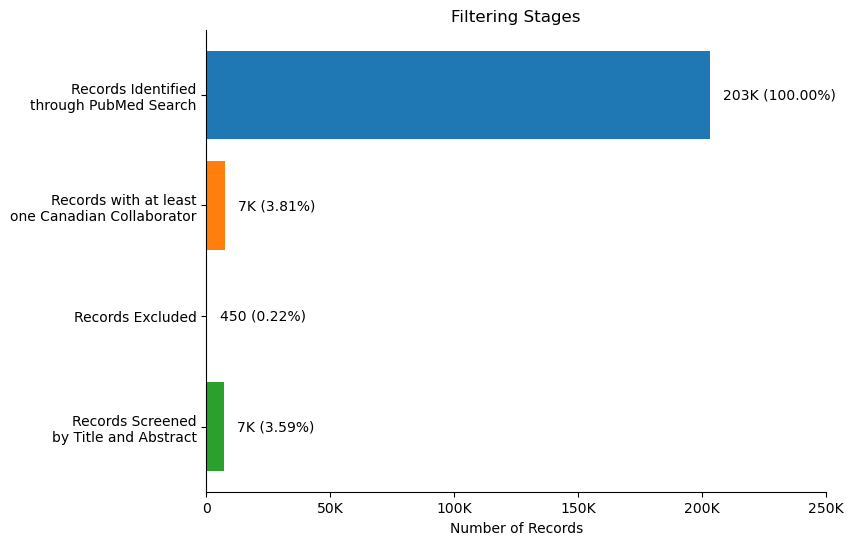

In [8]:
import matplotlib.pyplot as plt

# Data for the funnel chart
stages = [
    'Records Identified\nthrough PubMed Search',
    'Records with at least\none Canadian Collaborator',
    'Records Excluded',
    'Records Screened\nby Title and Abstract'
]

values = [203231, 7748, 450, 7298]

# Calculate percentages
percentages = [f"{value / values[0] * 100:.2f}%" for value in values]

# Function to format large numbers as "K" (thousands)
def format_number(num):
    if num >= 1000:
        return f'{num//1000}K'
    else:
        return str(num)

# Create the funnel chart
fig, ax = plt.subplots(figsize=(8, 6))

# Create a horizontal bar chart
bars = ax.barh(stages, values, color=['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c'])

# Add annotations for numbers and percentages
for bar, value, percent in zip(bars, values, percentages):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2, f'{format_number(value)} ({percent})', va='center')

# Set x-axis labels to be more readable
ax.set_xticks([0, 50000, 100000, 150000, 200000, 250000])
ax.set_xticklabels(['0', '50K', '100K', '150K', '200K', '250K'])

# Add title and labels
ax.set_title('Filtering Stages')
ax.set_xlabel('Number of Records')
ax.invert_yaxis()  # To display the funnel correctly

# Remove the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Show the chart
plt.show()


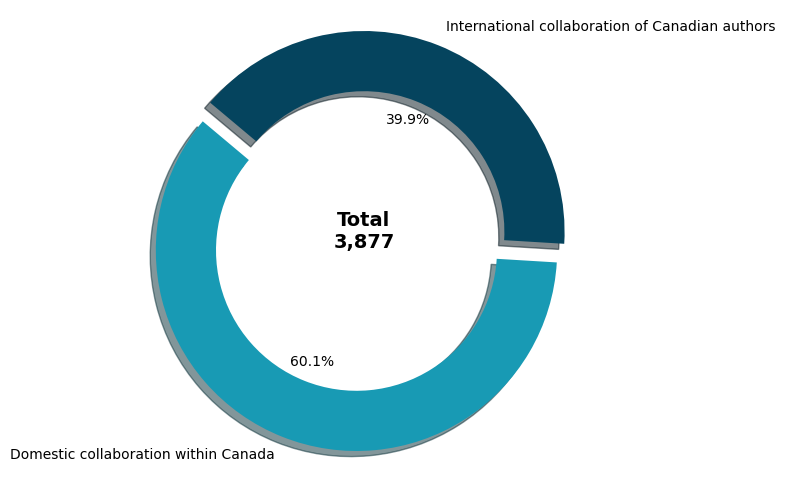

In [15]:
import matplotlib.pyplot as plt

# Data to plot
labels = ['Domestic collaboration within Canada', 'International collaboration of Canadian authors']
sizes = [2332, 1545]
colors = ['#189AB4', '#05445e']  # Updated colors for better visibility
explode = (0.1, 0)  # explode 1st slice

# Plot
plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140, wedgeprops=dict(width=0.3))

# Draw a circle in the center to make it a donut chart
centre_circle = plt.Circle((0,0),0.2,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add a central label with the total count
plt.text(0, 0, 'Total\n3,877', horizontalalignment='center', verticalalignment='center', 
         fontsize=14, fontweight='bold')

# plt.title('Distribution of Full-text Articles Assessed for Eligibility')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


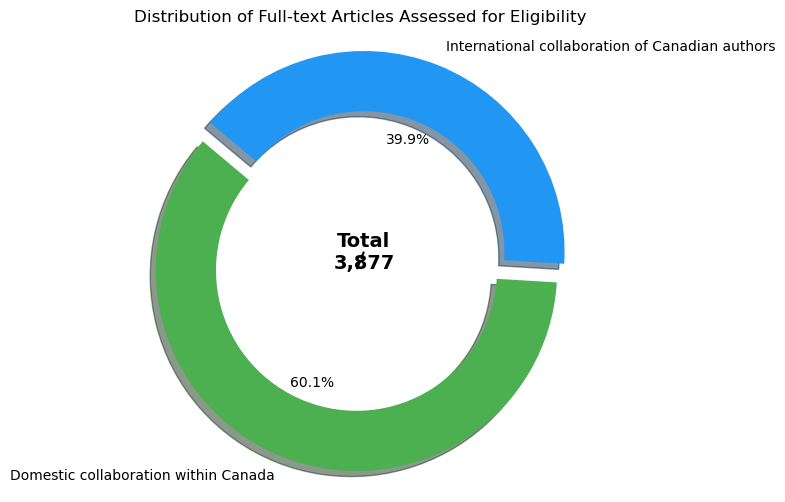

In [25]:
import matplotlib.pyplot as plt

# Data to plot
labels = ['Domestic collaboration within Canada', 'International collaboration of Canadian authors']
sizes = [2332, 1545]
colors = ['#4caf50', '#2196f3']  # Colors
explode = (0.1, 0)  # explode 1st slice

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors,
                                  autopct='%1.1f%%', shadow=True, startangle=140, wedgeprops=dict(width=0.3))

# Draw a circle in the center to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.2, fc='white')  # Standard hole size
fig.gca().add_artist(centre_circle)

# Add a central label with the total count
plt.text(0, 0, 'Total\n3,877', horizontalalignment='center', verticalalignment='center', 
         fontsize=14, fontweight='bold', color='black')

# Add line markers to labels manually
for wedge in wedges:
    # Get the center of the wedge
    x, y = wedge.center
    # Plot a line from the center to the outer edge
    ax.plot([0, x], [0, y], color='black', linestyle='--', linewidth=1.5)

plt.title('Distribution of Full-text Articles Assessed for Eligibility')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [27]:
import pandas as pd

# Load the CSV file
file_path = 'data-1723582661030.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataframe to understand its structure
data.head()

,pid,num_of_countries,country
0,28651909,2,"[[""China""], [""Canada""], [""China""], [""China""], ..."
1,28726811,4,"[[""Canada""], [""Canada""], [""Switzerland""], [""Ca..."
2,28756487,3,"[[""France""], [""France""], [""France""], [""France""..."
3,28771699,3,"[[""Brazil""], [""Israel""], [""Israel""], [""Canada""]]"
4,28853237,2,"[[""Russia""], [""Russia""], [""Russia""], [""Canada""..."


In [28]:
import ast

# Updated function to handle potential issues with parsing
def extract_unique_countries_safe(country_str):
    try:
        country_list = ast.literal_eval(country_str)
        # Flatten the list and get unique countries, handling potential index errors
        unique_countries = set([item[0] for item in country_list if len(item) > 0])
        return unique_countries
    except Exception as e:
        print(f"Error parsing: {country_str} | Error: {e}")
        return set()

# Apply the safe function to extract unique countries for each row
data['unique_countries'] = data['country'].apply(extract_unique_countries_safe)




In [29]:
data

,pid,num_of_countries,country,unique_countries
0,28651909,2,"[[""China""], [""Canada""], [""China""], [""China""], ...","{Canada, China}"
1,28726811,4,"[[""Canada""], [""Canada""], [""Switzerland""], [""Ca...","{Canada, Switzerland, Netherlands, Germany}"
2,28756487,3,"[[""France""], [""France""], [""France""], [""France""...","{Canada, United Kingdom, France}"
3,28771699,3,"[[""Brazil""], [""Israel""], [""Israel""], [""Canada""]]","{Canada, Israel, Brazil}"
4,28853237,2,"[[""Russia""], [""Russia""], [""Russia""], [""Canada""...","{Canada, Russia}"
...,...,...,...,...
2327,39002043,3,"[[""Canada""], [""United States""], [""Canada""], [""...","{Canada, Jersey, United States}"
2328,39009063,2,"[[""Belgium""], [""Belgium""], [""Canada""]]","{Canada, Belgium}"
2329,39012781,5,"[[""Australia""], [""Australia""], [""Australia""], ...","{Canada, Taiwan, Australia, Chile, Brazil}"
2330,39013639,3,"[[""Canada""], [""United Kingdom""], [""United Stat...","{Canada, United Kingdom, United States}"


In [30]:
# Filter rows where Canada is present and create a pair count of Canada with other countries
canada_relations = []
for countries in data['unique_countries']:
    if 'Canada' in countries:
        for country in countries:
            if country != 'Canada':
                canada_relations.append((country, 'Canada'))

# Convert the list to a DataFrame and count the occurrences
canada_relations_df = pd.DataFrame(canada_relations, columns=['Country', 'Canada'])
relation_count = canada_relations_df['Country'].value_counts().reset_index()
relation_count.columns = ['Country', 'Count']

relation_count

,Country,Count
0,United States,1186
1,China,292
2,United Kingdom,288
3,Germany,224
4,France,223
...,...,...
105,Macao,1
106,Senegal,1
107,Mali,1
108,Tanzania,1


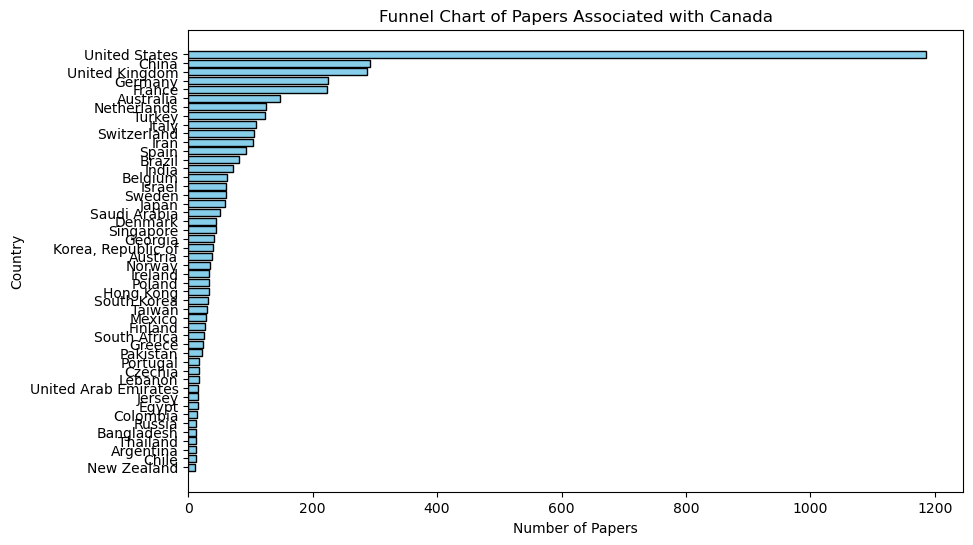

In [41]:
import matplotlib.pyplot as plt

# Sort the data in descending order
filtered_relation_count = relation_count[relation_count['Count'] > 10].sort_values(by='Count', ascending=False)

# Funnel chart data
countries = filtered_relation_count['Country']
counts = filtered_relation_count['Count']

# Plotting the funnel chart
plt.figure(figsize=(10, 6))
plt.barh(countries, counts, color='skyblue', edgecolor='black')

# Invert y-axis to have the largest count at the top
plt.gca().invert_yaxis()

# Add labels and title
plt.xlabel('Number of Papers')
plt.ylabel('Country')
plt.title('Funnel Chart of Papers Associated with Canada')

# Show the chart
plt.show()


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

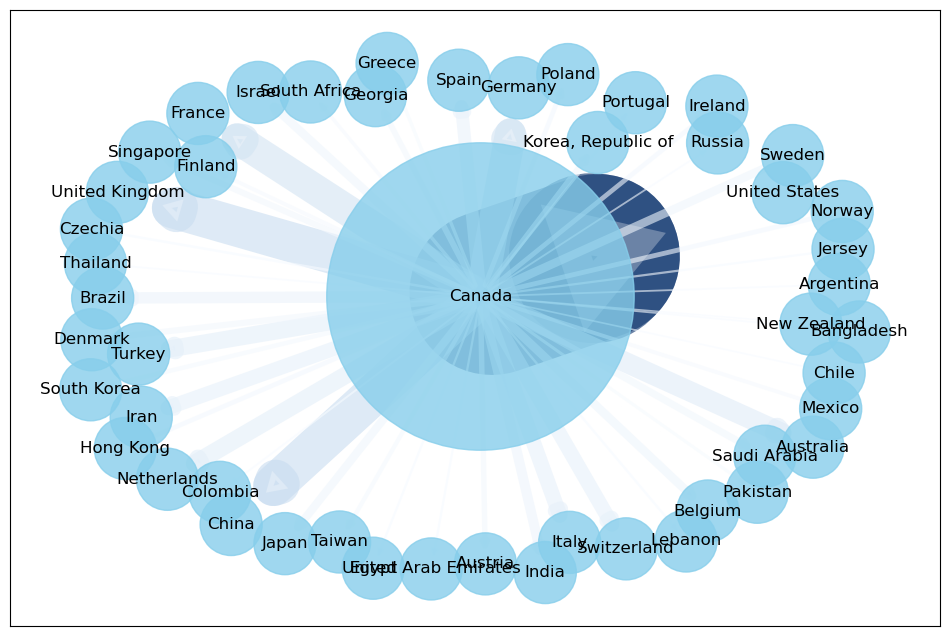

In [39]:
import matplotlib.pyplot as plt
import networkx as nx

# Filter out countries with fewer than 10 papers
filtered_relation_count = relation_count[relation_count['Count'] > 10]

# Create a directed graph
G = nx.DiGraph()

# Add edges to the graph with the weight as the count of relationships
for index, row in filtered_relation_count.iterrows():
    G.add_edge('Canada', row['Country'], weight=row['Count'])

# Set up the layout for the graph
plt.figure(figsize=(12, 8))  # Increase the figure size for better visibility
pos = nx.spring_layout(G, k=0.5, seed=42)  # Adjust 'k' for better spacing

# Draw the nodes with a size proportional to the degree
node_sizes = [1000 + 1000 * G.degree(n) for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.8)

# Draw the edges with thickness based on weight, using a color gradient
edge_weights = [G[u][v]['weight'] for u,v in G.edges()]
nx.draw_networkx_edges(G, pos, edgelist=G.edges(data=True), width=[w/10 for w in edge_weights],
                       edge_color=edge_weights, edge_cmap=plt.cm.Blues, alpha=0.6)

# Draw labels for nodes with a larger font size for better readability
nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif")

# Add a colorbar to indicate the weight of the relationships
sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=min(edge_weights), vmax=max(edge_weights)))
sm.set_array([])
plt.colorbar(sm, label='Number of Papers')

# Display the plot with a title
plt.title("Network of Relationships Between Canada and Countries with >10 Papers", fontsize=16)
plt.axis('off')  # Turn off the axis
plt.show()


In [42]:
relation_count.head(15)

,Country,Count
0,United States,1186
1,China,292
2,United Kingdom,288
3,Germany,224
4,France,223
5,Australia,147
6,Netherlands,125
7,Turkey,124
8,Italy,109
9,Switzerland,106
